In [10]:
import sympy as sm
import sympy.physics.mechanics as me
import time
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve, minimize
from scipy_dae.integrate import solve_dae, consistent_initial_conditions
#from scikits.odes.sundials.ida import IDA

import matplotlib.pyplot as plt


**A chain**

I simulate a hanging chain, which I model as a simple closed 2D n-link 
pendulum, where each link is modelled a a thin rod.
The two ends of the chain are fixed at $(0., 0.)$ and at $(EP_x, EP_y)$.

Three numerical integration methods are compared.

**Symbols**

- $O$: Reference frame
- $PO$: point fixed in $O$
- $A[i]$: body fixed frame of link $i$ with $0 \leq n < n$
- $Dmc[i]$: center of gravitiy of link $i$
- $P[i]$: point, where frame $A[i]$ joins frame $A[i+1]$
- $l$: length of the pendulum, that is each link has length = $\dfrac{l}{n}$

- $m$: mass of each link
- $iZZ$: moment of inertial of each link around $A[i].z$, relative to $Dmc[i]$
- $reibung$: speed dependent friction in each joint.

- $q[i]$: generalized coordinate of frame $A[i]$ relative to the inertial frame $O$.
- $u[i]$: angular speed dto.


- $EP$: end point of the chain, fixed in place. That is $P[n-1]$ should be at $EP$.
- $EP_x, EP_y$: its coordinates

In [11]:
# number of links. n > 2
n = 3

# if true, information about the mass matrix and the force vector will be
# printed
term_info = True

# if true solve_dae with both configuration and speed constraints, otherwise
# only with configuration constraints
speed_constr_too = True

#==================
start = time.time()

m, g, iZZ, l, reibung = sm.symbols('m, g, iZZ, l, reibung')
q = me.dynamicsymbols(f'q:{n}')
u = me.dynamicsymbols(f'u:{n}')

t = me.dynamicsymbols._t

A = sm.symbols(f'A:{n}', cls=me.ReferenceFrame)
Dmc = sm.symbols(f'Dmc:{n}', cls=me.Point)
P = sm.symbols(f'P:{n}', cls=me.Point)
rhs = list(sm.symbols(f'rhs:{n}'))

O = me.ReferenceFrame('O')
PO = me.Point('PO')
PO.set_vel(O, 0)

l1 = l/n
l2 = l/(2 * n)

A[0].orient_axis(O, q[0], O.z)
A[0].set_ang_vel(O, u[0] * O.z)

Dmc[0].set_pos(PO, l2*A[0].x)
Dmc[0].v2pt_theory(PO, O, A[0])
P[0].set_pos(PO, l1*A[0].x)
P[0].v2pt_theory(PO, O, A[0])

for i in range(1, n):
    A[i].orient_axis(O, q[i], O.z)
    A[i].set_ang_vel(O, u[i] * O.z)

    Dmc[i].set_pos(P[i-1], l2*A[i].x)
    Dmc[i].v2pt_theory(P[i-1], O, A[i])
    P[i].set_pos(P[i-1], l1*A[i].x)
    P[i].v2pt_theory(P[i-1], O, A[i])

*Find the configuration constraint and derive the speed constraints from it*\
The last point $P[n-1]$ is required to be fixed at $(EP_x / EP_y)$.\
*laenge* is used to check how well the speed constraints are fulfilled 
initially. 

In [12]:
EP = me.Point('EP')
EPx, EPy = sm.symbols('EPx, EPy')

EP_pos = EP.set_pos(PO, EPx*O.x + EPy*O.y)
EP_pos = EP.pos_from(PO)
Pn_pos = P[0].pos_from(PO) + sum([P[i+1].pos_from(P[i]) for i in range(n-1)])

constraint = EP_pos - Pn_pos

constraintX = me.dot(constraint, O.x)
constraintY = me.dot(constraint, O.y)
constraint_matrix = sm.Matrix([constraintX, constraintY])
constraint_matrix_dt = constraint_matrix.diff(t)

# needed to find valid initial conditions
laenge = sm.sqrt(constraintX**2 + constraintY**2)

constraint_dict = {sm.Derivative(q[i], t): u[i] for i in range(n)}
constraintXdt = constraintX.diff(t).subs(constraint_dict)
constraintYdt = constraintY.diff(t).subs(constraint_dict)
constraintdt_matrix = sm.Matrix([constraintXdt, constraintYdt])

# Solve the velocity constraints for the dependent speeds.
# This is needed to find valid initial conditions below.
matrix_A = constraintdt_matrix.jacobian((u[n-2], u[n-1]))
vector_b = constraintdt_matrix.subs({u[n-2]: 0., u[n-1]: 0.})
loesung  = matrix_A.LUsolve(-vector_b)

if term_info == True:
    print('loesung DS', me.find_dynamicsymbols(loesung))
    print('loesung FS', loesung.free_symbols)
    print(f'loesung has {sm.count_ops(loesung):,} operations')

loesung DS {u0(t), q1(t), q0(t), q2(t)}
loesung FS {l, t}
loesung has 85 operations


**Kane's Equations**

In [13]:
BODY = []
for i in range(n):
    inertia = me.inertia(A[i], 0., 0., iZZ)
    body = me.RigidBody('body' + str(i), Dmc[i], A[i], m, (inertia, Dmc[i]))
    BODY.append(body)

FL1 = [(Dmc[i], -m*g*O.y) for i in range(n)]
Torque = [(A[i], -u[i] * reibung * A[i].z) for i in range(n)]
FL = FL1 + Torque

# kinematic differential equations
kd = sm.Matrix([u[i] - q[i].diff(t) for i in range(n)])

# speed constraints
speed_constr = [u[n-2] - loesung[0], u[n-1] - loesung[1]]

u_ind = [u[i] for i in range(n-2)]
u_dep = [u[n-2], u[n-1]]

KM = me.KanesMethod(O,
                    q_ind=q,
                    u_ind=u_ind,
                    u_dependent=u_dep,
                    kd_eqs=kd,
                    velocity_constraints=speed_constr)

fr, frstar = KM.kanes_equations(BODY, FL)

MM = KM.mass_matrix_full
if term_info == True:
    print('MM DS', me.find_dynamicsymbols(MM))
    print('MM free symbols', MM.free_symbols)
    print(f'MM contains {sm.count_ops(MM):,} operations, '
          f'{sm.count_ops(sm.cse(MM)):,} after cse', '\n')

force = KM.forcing_full
if term_info == True:
    print('force DS', me.find_dynamicsymbols(force))
    print('force free symbols', force.free_symbols)
    print(f'force contains {sm.count_ops(force):,} operations, '
          f'{sm.count_ops(sm.cse(force)):,} after cse', '\n')

print(f'it took {time.time() - start:.3f} sec to set up Kanes equations for '
      f'{n} links')

MM DS {q1(t), q0(t), q2(t)}
MM free symbols {m, l, t, iZZ}
MM contains 409 operations, 72 after cse 

force DS {q0(t), u0(t), q1(t), u2(t), q2(t), u1(t)}
force free symbols {m, reibung, g, l, t}
force contains 684 operations, 154 after cse 

it took 4.481 sec to set up Kanes equations for 3 links


Functions for the kinetic and the potential energies.

In [14]:
kin_energie = sum([koerper.kinetic_energy(O)
                   for koerper in BODY])
pot_energie = sum([m*g*me.dot(koerper.pos_from(PO), O.y) for koerper in Dmc])

Compile symbolic functions.

In [15]:
start1 = time.time()

qL = q + u_ind + u_dep
qL1 = q + u_ind
qL2 = [q[i] for i in range(n-2)]
pL = [m, g, l, iZZ, reibung, EPx, EPy]

MM_lam = sm.lambdify(qL + pL, MM, cse=True)
force_lam = sm.lambdify(qL + pL, force, cse=True)

kin_lam = sm.lambdify(qL + pL, kin_energie, cse=True)
pot_lam = sm.lambdify(qL + pL, pot_energie, cse=True)

loesung_lam = sm.lambdify(qL1 + pL, loesung, cse=True)
constraint_lam = sm.lambdify([q[n-2], q[n-1]] + qL2 + pL, constraint_matrix,
                             cse=True)
laenge_lam = sm.lambdify(q + pL, laenge, cse=True)
constraintdt_lam = sm.lambdify(qL + pL, constraintdt_matrix, cse=True)

print(f'it took {time.time()-start1:.3f} sec to do the lambdification')

it took 0.112 sec to do the lambdification


When integrating with solve_dae the constraints must be appended to the
equations of motion, so they must be compiled.

In [16]:
constraint_dae_lam = sm.lambdify(qL + pL, constraint_matrix, cse=True)
constraintdt_dae_lam = sm.lambdify(qL + pL, constraintdt_matrix, cse=True)

**Numerical Integration**

Define the initial values and the parameters.\
For more than a few links, it is difficult to get initial generalized 
coordinates $q[i]$ which fit the configuration constraint: if I just 
'randomly set $q[0]....q[n-3]$ there may not be a solution for the dependent 
generalized coordinates $q[n-2], q[n-1]$.\
So I get approximate generalized coordinates by numerically solving 
$\min \limits_{q[0]...q[n-1]} (| config. constraint |)$ for $q[0]....q[n-1]$. 
*method = 'Nelder-Meat'* in *minimize(..)* finds good minimal values even for 
larger n, while *no method* even failed with n = 10, depending on where the 
fixed point of $P[n-1]$ was located. There are many feasible solutions, 
the one picked likely depends on the initial conditions given to 
*minimize(..)*, but I did not study this.\
The values produced by *minimize(..)* serve as ininital conditions to 
numerically solve for $q[n-2], q[n-1]$. This improves how well the 
configuration constraints are fulfilled initially.

Finally I calculate how well the initial generalized coordinates and speeds 
fulfill the configuaration constraint and the resulting speed constraints.

In [17]:
# Input variables

m1 = 1.
g1 = 9.8
l1 = 30.
reibung1 = 0.0

# just starting guess for below.
q1 = [np.random.choice((1, -1)) for _ in range(n)]

# setting the angular velocities.
u1 = [0. for _ in range(n)]

EPx1 = 10.  # Must be > 0, else the catenary will not work.
EPy1 = 3.

# =======================================================================
# =======================================================================
# Set the data for the numerical integrations.
intervall = 30.0  # duration of the integration.
punkte = 25  # number of points per sec to be evaluated at.
atol = 1.e-6  # valid for all integrators
rtol= 1.e-3  # valid for all integrators
max_step = 0.1
# =======================================================================
# =======================================================================

start1 = time.time()
schritte = int(intervall * punkte)
times = np.linspace(0., intervall, schritte)
t_span = (0., intervall)

iZZ1 = 1./12. * m1 * (l1/n)**2  # inertia of a rod about its center of mass.

pL_vals = [m1, g1, l1, iZZ1, reibung1, EPx1, EPy1]

if np.sqrt(EPx1**2 + EPy1**2) > l1:
    raise Exception('endpoint to far away from (0/0)')

# find generalized coordinates to fullfill the configuration constraints


def func1(x0, args):
    return laenge_lam(*x0, *args)


X0 = tuple((q1))
X0 = tuple(([1.] * n))

# Iternation sometimes helps here.
for _ in range(6):
    t0 = minimize(func1, X0, pL_vals, method='Nelder-Mead')
    X0 = t0.x

print(f'error of initial guess is  {laenge_lam(*X0, *pL_vals):.3e} '
      'achieved by minimizing')

# Improve the accuracy by explicitly solving for the dependent coordinates
# using the results of the above.


def func2(X0, args):
    return constraint_lam(*X0, *args).reshape(2)


args = [X0[i] for i in range(n-2)] + pL_vals
Z0 = (X0[n-2], X0[n-1])
for _ in range(6):
    t0 = fsolve(func2, Z0, args)
    Z0 = t0
    Q0 = [Z0[0], Z0[1]] + [X0[i] for i in range(n-2)]
print(f'error of improved guess is {laenge_lam(*Q0, *pL_vals):.3e}'
     + ' achieved by nuerically solve for the dependent coordinates', '\n')

# find the dependent speeds to match the independet speeds
U0 = [u1[i] for i in range(n-2)]
t0 = loesung_lam(*Q0, *U0, *pL_vals)
u1[n-2] = t0[0][0]
u1[n-1] = t0[1][0]

y0 = Q0 + U0 + [u1[n-2], u1[n-1]]

print(f'error in the initial speed constraints are X: '
      f'{constraintdt_lam(*y0, *pL_vals)[0][0]:.3e} /'
      f' Y: {constraintdt_lam(*y0, *pL_vals)[1][0]:.3e}', '\n')

print(f'it took {time.time()-start1:.3f} sec to find suitable initial '
      'conditions')

error of initial guess is  2.652e-10 achieved by minimizing
error of improved guess is 4.441e-16 achieved by nuerically solve for the dependent coordinates 

error in the initial speed constraints are X: 0.000e+00 / Y: 0.000e+00 

it took 0.015 sec to find suitable initial conditions


Numerical integration with **solve_ivp**

In [18]:
y0 = Q0 + U0 + [u1[n-2], u1[n-1]]
print(f'initial conditions: {np.array(y0).flatten()}', '\n')
def gradient(t, y, args):
    sol = np.linalg.solve(MM_lam(*y, *args), force_lam(*y, *args))
    return sol.squeeze()

start2 = time.time()
resultat1 = solve_ivp(gradient, t_span, y0, t_eval = times, args=(pL_vals,),
                      method='Radau',
                      atol=atol, rtol=rtol,
                      max_step=max_step)
ende = time.time()
resultat = resultat1.y.T
print('resultat shape', resultat.shape, '\n')
print(resultat1.message, '\n')

print(f"To numerically integrate an intervall of {intervall} sec the routine "
      f"cycled {resultat1.nfev} times and it took {ende - start2:.3f} sec ", '\n')

initial conditions: [-1.41231409  0.29835277  1.68468399  0.          0.          0.        ] 

resultat shape (750, 6) 

The solver successfully reached the end of the integration interval. 

To numerically integrate an intervall of 30.0 sec the routine cycled 2116 times and it took 0.118 sec  



Numerical Integfration using **solve_dae**

In [20]:
if speed_constr_too:
    y0 = Q0 + U0 + [u1[n-2], u1[n-1]] + [0., 0., 0., 0.]  # two help variables for the dae solver
    yp = np.zeros_like(y0)
else:
    y0 = Q0 + U0 + [u1[n-2], u1[n-1]] + [0., 0.]  # two help variables for the dae solver
    yp = np.zeros_like(y0)


if speed_constr_too:

    def gradient(t, y, yp, args):
        y_dae = y[0: -4]
        sol = np.linalg.solve(MM_lam(*y_dae, *args), force_lam(*y_dae, *args))
        # Then the speed an the configuration constraints are appended.
        sol = np.vstack((sol, constraintdt_dae_lam(*y_dae, *args),
                         constraint_dae_lam(*y_dae, *args)))
        return np.array(sol).squeeze() - yp

else:

    def gradient(t, y, yp, args):
        y_dae = y[0: -2]
        yp_dae = yp[0: -2]
        # sol = np.linalg.solve(MM_lam(*y_dae, *args), force_lam(*y_dae, *args))
        sol = MM_lam(*y_dae, *args) @ yp_dae - force_lam(*y_dae, *args)
        # The configuration constraints are appended.
        sol = np.vstack((sol, constraint_dae_lam(*y_dae, *args)))
        return np.array(sol).squeeze() - yp


y0 = np.array(y0)
yp = np.array(yp)

print(f"y0: {y0}")
print(f"yp0: {yp}")

start2 = time.time()
resultat1 = solve_dae(gradient, t_span, y0, yp, t_eval=times, args=(pL_vals,),
                      method='Radau',
                      atol=atol, rtol=rtol,
                      max_step=max_step)
ende = time.time()
resultat_dae = resultat1.y.T
print('resultat shape', resultat_dae.shape, '\n')

print(resultat1.message, '\n')

print(f"To numerically integrate an intervall of {intervall} sec the routine "
      f"cycled {resultat1.nfev} times and it took {ende - start2:.3f} sec ",
      '\n')

y0: [-1.41231409  0.29835277  1.68468399  0.          0.          0.
  0.          0.          0.          0.        ]
yp0: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
resultat shape (750, 10) 

The solver successfully reached the end of the integration interval. 

To numerically integrate an intervall of 30.0 sec the routine cycled 2226 times and it took 0.176 sec  



Numerical integration with **IDA**

In [ ]:
res = np.ones((2*n + 2,))

y0 = np.array((Q0 + U0 + [u1[n-2], u1[n-1]]))

print(f"initial conditions for the DAE solver: \n {y0}", '\n')

# IDA also need initial values for d/dt y0, hence the rhs of the eoms must be
# calculated at y0
y0p = np.linalg.solve(MM_lam(*y0, *pL_vals), force_lam(*y0, *pL_vals))
print(f"initial derivatives for the DAE solver: \n {y0p}", '\n')
y0p = y0p.reshape(-1)


def gradient(t, y, yp, res, args):
    yp = yp.reshape(-1, 1)
    sol = (MM_lam(*y, *args) @ yp - force_lam(*y, *args))
#    print(f"sol: {sol.shape}")
    for i in range(len(yp)):
        res[i] = sol[i][0]

    # now the constraints are added
    res[-2] = constraint_dae_lam(*y, *args)[0][0]
    res[-1] = constraint_dae_lam(*y, *args)[1][0]
    yp = yp.reshape(-1, 1)
#    print(f"residual at initial conditions: {res}, y0p: {yp.shape}, ")

# Check if the residual is close to zero at the initial conditions
gradient(0, y0, y0p, res, pL_vals)
print(f"residual at initial conditions: \n {res}")
assert np.allclose(res, 0., atol=1.e-12), ("residual is not close to zero at "
    "the initial conditions")

Set up the solver.

In [ ]:
print('Y0', y0)
print('Y0p', y0p)
solver = IDA(
    gradient,
    rtol=rtol,
    atol=atol,
    algebraic_vars_idx=[2*n, 2*n+1],
    user_data=pL_vals,
    max_steps=max_step,
    old_api=False)

start2 = time.time()
solution = solver.solve(times, y0, y0p)
ende = time.time()
print('IDA message:', solution.message, '\n')
ts_ida = solution.values.t
xs_ida = solution.values.y
print('xs_ida shape', xs_ida.shape, '\n')

con_ida = np.ones((len(ts_ida), 2))
for i in range(len(ts_ida)):
    con_ida[i] = constraint_dae_lam(*[xs_ida[i, j]
                                      for j in range(xs_ida.shape[1])],
                                    *pL_vals).flatten()

print(f"To numerically integrate an intervall of {intervall} sec the routine "
      f"took {ende - start2:.3f} sec ")

if xs_ida.shape[0] == schritte:
    IDA_success = True
else:
    IDA_success = False



Plot the **energies**.

In [21]:
kin_np = np.empty(schritte)
pot_np = np.empty(schritte)
total_np = np.empty(schritte)

if not IDA_success:
    no_plots = 2
    fig_height = 6
else:
    no_plots = 3
    fig_height = 8
fig, ax = plt.subplots(no_plots, 1, figsize=(10, fig_height), sharex=True,
                       layout='constrained')

# Energies with solve_ivp
for i in range(schritte):
    kin_np[i] = kin_lam(*[resultat[i, j] for j in range(resultat.shape[1])],
                        *pL_vals)
    pot_np[i] = pot_lam(*[resultat[i, j] for j in range(resultat.shape[1])],
                        *pL_vals)
    total_np[i] = kin_np[i] + pot_np[i]

if reibung1 == 0.:
    max_total = np.max(np.abs(total_np))
    min_total = np.min(np.abs(total_np))
    delta = max_total - min_total
    print(f'with solve_ivp max deviation of total energy from zero is '
          f'{delta/max_total * 100:.3e} % of max. total energy')

for i, j in zip((kin_np, pot_np, total_np), ('kinetic energy',
                                             'potential energy',
                                             'total energy')):
    ax[0].plot(times, i, label=j)
ax[0].set_title(f'Energies of the system, using solve_ivp, '
                f'friction = {reibung1}')
ax[0].set_xlabel('time (sec)')
ax[0].set_ylabel('energy (Nm)')
ax[0].legend()

# Energies with scipy_dae
if speed_constr_too:
    delay = 4
    msg = 'with both configuration and speed constraints'
else:
    delay = 2
    msg = 'with only configuration constraints'

for i in range(schritte):
    kin_np[i] = kin_lam(*[resultat_dae[i, j]
                          for j in range(resultat_dae.shape[1] - delay)],
                        *pL_vals)
    pot_np[i] = pot_lam(*[resultat_dae[i, j]
                          for j in range(resultat_dae.shape[1] - delay)],
                        *pL_vals)
    total_np[i] = kin_np[i] + pot_np[i]

if reibung1 == 0.:
    max_total = np.max(np.abs(total_np))
    min_total = np.min(np.abs(total_np))
    delta = max_total - min_total
    print(r'with solve_dae max deviation of total energy from zero is '
          f'{delta/max_total * 100:.3e} % of max. total energy')

for i, j in zip((kin_np, pot_np, total_np), ('kinetic energy',
                                             'potential energy',
                                             'total energy')):
    ax[1].plot(times, i, label=j)
ax[1].set_title(f'Energies of the system, using scipy_dae, '
                f'friction = {reibung1}, {msg}')
ax[1].set_xlabel('time (sec)')
ax[1].set_ylabel('energy (Nm)')
ax[1].legend()

if IDA_success:
    # Energies with IDA
    for i in range(schritte):
        kin_np[i] = kin_lam(*[xs_ida[i, j] for j in range(xs_ida.shape[1])],
                            *pL_vals)
        pot_np[i] = pot_lam(*[xs_ida[i, j] for j in range(xs_ida.shape[1])],
                            *pL_vals)
        total_np[i] = kin_np[i] + pot_np[i]

    if reibung1 == 0.:
        max_total = np.max(np.abs(total_np))
        min_total = np.min(np.abs(total_np))
        delta = max_total - min_total
        print(f'with IDA max deviation of total energy from zero is '
              f'{delta/max_total * 100:.3e} % of max. total energy')

    for i, j in zip((kin_np, pot_np, total_np), ('kinetic energy',
                                                 'potential energy',
                                                 'total energy')):
        ax[2].plot(times, i, label=j)
        ax[2].set_title(f'Energies of the system, using IDA, '
                        f'friction = {reibung1}')
    ax[2].set_xlabel('time (sec)')
    ax[2].set_ylabel('energy (Nm)')
    _ = ax[2].legend()

else:
    print('IDA failed to integrate the system, hence no energy plot for IDA.')


NameError: name 'IDA_success' is not defined

Check, how well the **configuration constraint** and the **speed constraints** are kept\
Ideally, of course, they should be zero.

NameError: name 'msg' is not defined

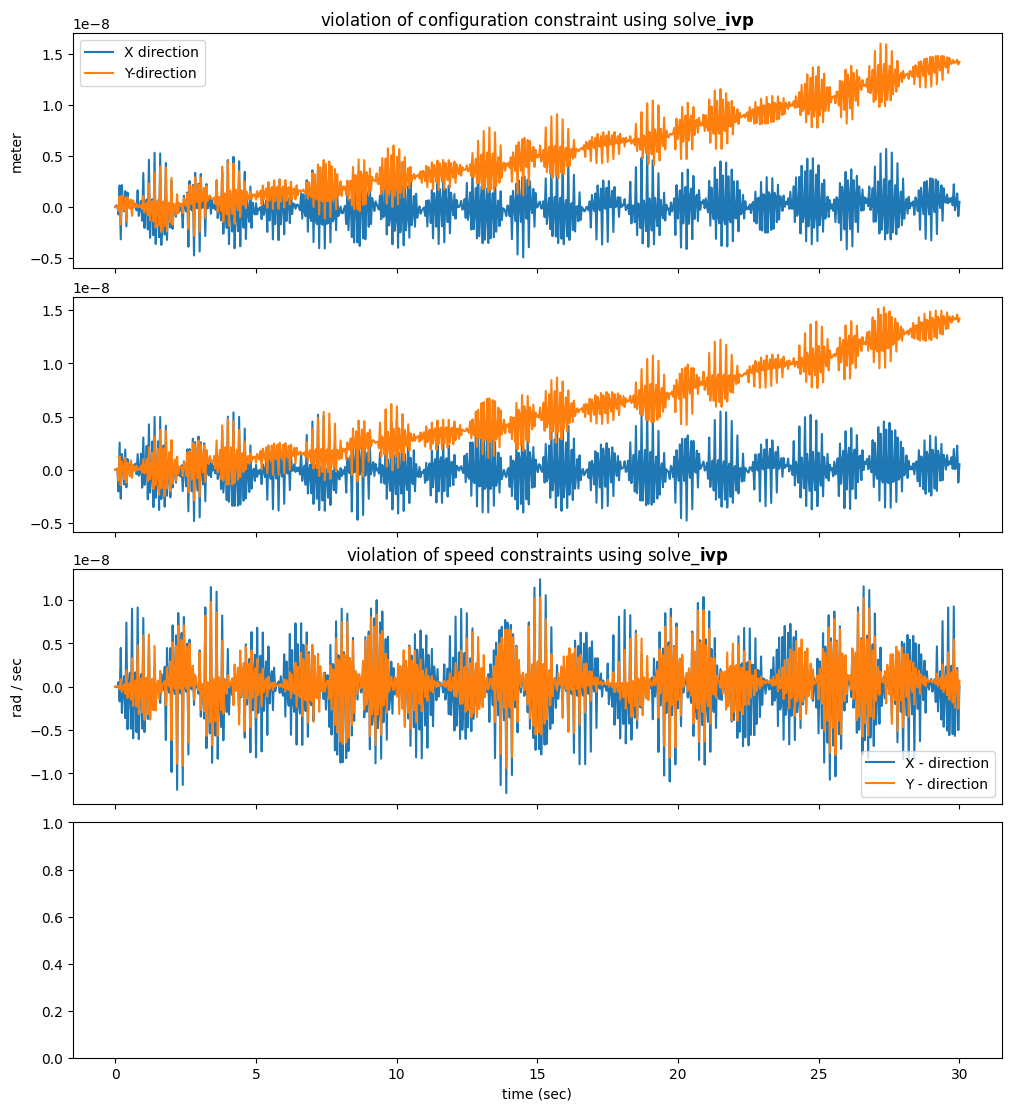

In [23]:
X_np = np.empty(schritte)
Y_np = np.empty(schritte)

# if not IDA_success:
if True:
    no_plots = 4
    fig_height = 11
    p0, p1, p2, p3 = 0, 2, 1, 3
else:
    no_plots = 6
    fig_height = 14
    p0, p1, p2, p3, p4, p5 = 0, 3, 1, 4, 2, 5
fig, ax = plt.subplots(no_plots, 1, figsize=(10, fig_height),
                       layout='constrained', sharex=True)

ax[-1].set_xlabel('time (sec)')

# Configuration violation with solve_ivp
for i in range(schritte):
    X_np[i] = constraint_lam(resultat[i, n-2], resultat[i, n-1],
        *[resultat[i, j] for j in range(n-2)], *pL_vals)[0][0]
    Y_np[i] = constraint_lam(resultat[i, n-2], resultat[i, n-1],
        *[resultat[i, j] for j in range(n-2)], *pL_vals)[1][0]

for i, j in zip((X_np, Y_np), ('X direction', 'Y-direction')):
    ax[p0].plot(times, i, label=j)
ax[p0].set_title(r'violation of configuration constraint using solve_$\bf{ivp}$')
ax[p0].set_ylabel('meter')
ax[p0].legend()

# speed constraint violation with solve_ivp
for i in range(schritte):
    X_np[i] = constraintdt_lam(*[resultat[i, j]
                                 for j in range(resultat.shape[1])],
                               *pL_vals)[0][0]
    Y_np[i] = constraintdt_lam(*[resultat[i, j]
                                 for j in range(resultat.shape[1])],
                                *pL_vals)[1][0]

for i, j in zip((X_np, Y_np), ('X - direction', 'Y - direction')):
    ax[p1].plot(times, i, label=j)
ax[p1].set_title(r'violation of speed constraints using solve_$\bf{ivp}$')
ax[p1].set_ylabel('rad / sec')
ax[p1].legend()

# configuration violation with solve_dae
for i in range(schritte):
    X_np[i] = constraint_lam(resultat_dae[i, n-2], resultat_dae[i, n-1],
        *[resultat_dae[i, j] for j in range(n-2)], *pL_vals)[0][0]
    Y_np[i] = constraint_lam(resultat_dae[i, n-2], resultat_dae[i, n-1],
        *[resultat_dae[i, j] for j in range(n-2)], *pL_vals)[1][0]

for i, j in zip((X_np, Y_np), ('X - direction', 'Y - direction')):
    ax[p2].plot(times, i, label=j)

ax[p2].set_title(r'violation of configuration constraint using solve_$\bf{dae}$ '
                +msg)
ax[p2].set_ylabel('meter')
ax[p2].legend()

# speed constraint violation with solve_dae
X_np = np.empty(schritte)
Y_np = np.empty(schritte)

for i in range(schritte):
    X_np[i] = constraintdt_lam(*[resultat_dae[i, j]
                                 for j in range(resultat_dae.shape[1] - delay)],
                               *pL_vals)[0][0]
    Y_np[i] = constraintdt_lam(*[resultat_dae[i, j]
                                 for j in range(resultat_dae.shape[1] - delay)],
                                *pL_vals)[1][0]
for i, j in zip((X_np, Y_np), ('X - direction', 'Y - direction')):
    ax[p3].plot(times, i, label=j)
ax[p3].set_title(r'violation of speed constraints using solve_$\bf{dae}$, '
                + msg)
ax[p3].set_xlabel('time (sec)')
ax[p3].set_ylabel('rad / sec')
_ = ax[p3].legend()

if IDA_success:
    # configuration violation with solve_IDA
    for i in range(schritte):
        X_np[i] = constraint_lam(xs_ida[i, n-2], xs_ida[i, n-1],
            *[xs_ida[i, j] for j in range(n-2)], *pL_vals)[0][0]
        Y_np[i] = constraint_lam(xs_ida[i, n-2], xs_ida[i, n-1],
            *[xs_ida[i, j] for j in range(n-2)], *pL_vals)[1][0]

    for i, j in zip((X_np, Y_np), ('X - direction', 'Y - direction')):
        ax[p4].plot(times, i, label=j)

    ax[p4].set_title((r'violation of configuration constraint using solve_'
                 r'$\bf{IDA}$'))
    ax[p4].set_ylabel('meter')
    ax[p4].legend()


    # speed constraint violation with solve_IDA
    X_np = np.empty(schritte)
    Y_np = np.empty(schritte)

    for i in range(schritte):
        X_np[i] = constraintdt_lam(*[xs_ida[i, j]
                                     for j in range(xs_ida.shape[1])],
                                   *pL_vals)[0][0]
        Y_np[i] = constraintdt_lam(*[xs_ida[i, j]
                                     for j in range(xs_ida.shape[1])],
                                   *pL_vals)[1][0]
    for i, j in zip((X_np, Y_np), ('X - direction', 'Y - direction')):
        ax[p5].plot(times, i, label=j)
    ax[p5].set_title(r'violation of speed constraints using solve_$\bf{IDA}$')
    ax[p5].set_xlabel('time (sec)')
    ax[p5].set_ylabel('rad / sec')

else:
    print('IDA failed to integrate the system, hence no constraint '
          'violation plot for IDA.')


Compare the last two (dependent) angles

NameError: name 'IDA_success' is not defined

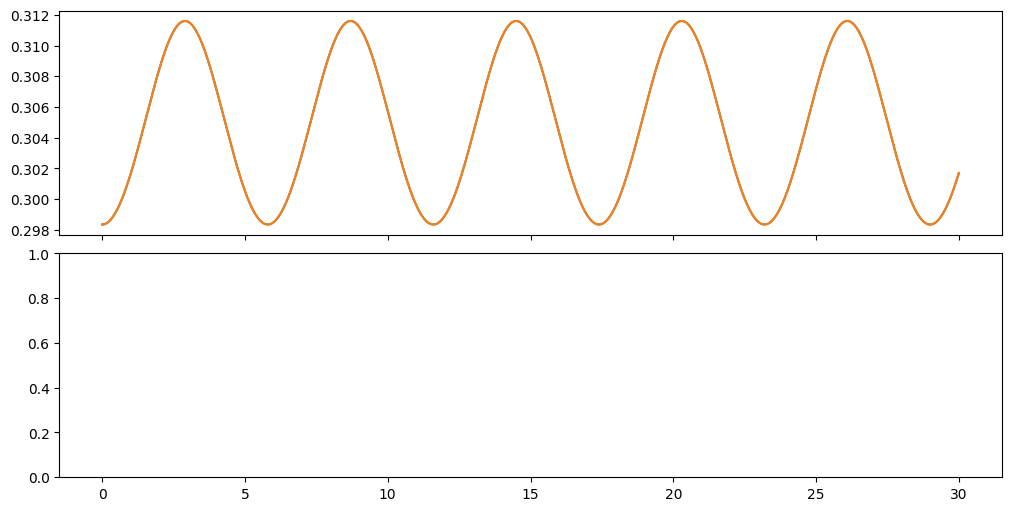

In [24]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True,
                       layout='constrained')

ax[0].plot(times,resultat[:, n-2], label=f'$q_{{{n-1}}}$ using solve_ivp')
ax[0].plot(times,resultat_dae[:, n-2], label=f'$q_{{{n-1}}}$ using solve_dae')
if IDA_success:
    ax[0].plot(ts_ida, xs_ida[:, n-2], label=f'$q_{{{n-1}}}$ using IDA')
ax[0].set_title(f'generalized coordinate $q_{{{n-1}}}$ of the system')
ax[0].set_ylabel('angle (rad)')
ax[0].legend()
ax[1].plot(times,resultat[:, n-1], label=f'$q_{{{n}}}$ using solve_ivp')
ax[1].plot(times,resultat_dae[:, n-1], label=f'$q_{{{n}}}$ using solve_dae')
if IDA_success:
    ax[1].plot(ts_ida, xs_ida[:, n-1], label=f'$q_{{{n}}}$ using IDA')
ax[1].set_title(f'generalized coordinate $q_{{{n}}}$ of the system')
ax[1].set_xlabel('time (sec)')
ax[1].set_ylabel('angle (rad)')
_ = ax[1].legend()
